#  <font color = 'red'><b> BÁO CÁO PHÂN TÍCH KHAI PHÁ DỮ LIỆU (DATA MINING) - DỮ LIỆU HÀNG KHÔNG </b></font><br>

##  <font color = 'blue'><b> 1) **Mục tiêu data mining:** </b></font><br>  
- Phân tích và khai phá dữ liệu **theo độ trễ chuyến bay (Delay Analysis)**
- Xác định các hãng bay có mức độ trễ cao hoặc thấp
- Phân nhóm (Clustering) các hãng bay dựa trên hành vi trễ chuyến  
- Dự đoán chuyến bay có bị trễ hay không
- Hỗ trợ đánh giá hiệu suất hoạt động và đề xuất cải thiện chất lượng dịch vụ

##  <font color = 'blue'><b> 2) **Tải các file csv** </b></font><br>  


###  <font color = 'purple'><b> a) **Upload file** </b></font><br>  
- Chọn tất cả các file cần sử dụng trong mô hình để thực hiện data mining
- Sau đây là các file cần sử dụng  
   - fact.csv
  - dimReason.csv  
  - dimDate.csv
  - dimAirport.csv
  - dimAirline.csv



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fact.csv to fact.csv
Saving dimReason.csv to dimReason.csv
Saving dimDate.csv to dimDate.csv
Saving dimAirport.csv to dimAirport.csv
Saving dimAirline.csv to dimAirline.csv


###  <font color = 'purple'><b> b) **Kiểm tra các file** </b></font><br>  
- Tiến hành kiểm tra xem các file vừa upload lên có tồn tại hay chưa và nếu đã có đủ thì nó sẽ hiện tất cả như bên dưới

In [37]:
import os
os.listdir()

['.config',
 'dimAirport.csv',
 'dimDate.csv',
 'dimReason.csv',
 'fact.csv',
 'dimAirline.csv',
 'sample_data']

###  <font color = 'purple'><b> c) **Đọc lại dữ liệu** </b></font><br>  
- Thực hiện đọc lại dữ liệu một lần nữa và in ra màn hình xem các dữ liệu trong mỗi bảng đã đúng chưa? Giống với dữ liệu thực tế từ file csv chưa và đây cũng là bước load dữ liệu

In [ ]:
import pandas as pd
import numpy as np

fact = pd.read_csv('fact.csv')
dimAirline = pd.read_csv('dimAirline.csv')
dimAirport = pd.read_csv('dimAirport.csv')
dimDate = pd.read_csv('dimDate.csv')
dimReason = pd.read_csv('dimReason.csv')

print(fact.shape)
fact.head()

(105236, 30)


,Flight_ID,Date_Key,Airline_ID,Origin_Airport_ID,Dest_Airport_ID,Cancel_Reason_ID,Flight_Number,Tail_Number,Scheduled_Dep_Time,Departure_Time,...,Scheduled_Time,Elapsed_Time,Delay_System,Delay_Security,Delay_Airline,Delay_Weather,Delay_LateAircraft,Is_Cancelled,Is_Diverted,Status
0,1,20150101,11,6,4,NaN,1001,N23721,738,735,...,125,105,0.0,0.0,0.0,0.0,0.0,False,False,1
1,2,20150101,1,2,3,B,1041,N3DEAA,1510,0,...,175,0,0.0,0.0,0.0,0.0,0.0,True,False,1
2,3,20150101,1,3,2,B,1041,N3DEAA,1105,0,...,135,0,0.0,0.0,0.0,0.0,0.0,True,False,1
3,4,20150101,11,1,6,NaN,1058,N38459,715,708,...,133,137,0.0,0.0,0.0,0.0,0.0,False,False,1
4,5,20150101,1,1,3,NaN,1068,N485AA,1910,1959,...,210,209,0.0,0.0,0.0,0.0,48.0,False,False,1


##  <font color = 'blue'><b> 3) **Tích hợp dữ liệu từ Fact và Dimension** </b></font><br>  
- Trước khi thực hiện Data Mining, dữ liệu cần được tích hợp đầy đủ từ bảng Fact và các bảng Dimension trong mô hình Data Warehouse. Việc tích hợp này giúp tạo ra một tập dữ liệu phân tích thống nhất, chứa đầy đủ thông tin nghiệp vụ và các thuộc tính mô tả cần thiết cho quá trình khai phá dữ liệu.
- Trước khi thực hiện join các bảng lại thì cần viết lệnh để in ra tất cả các thuộc tính trong mỗi bảng để đảm bảo tính chính xác khi thực hiện và đoạn mã bên dưới phục vụ cho mục đích này.

In [ ]:
print(fact.columns)
print(dimAirline.columns)
print(dimAirport.columns)
print(dimReason.columns)



Index(['Flight_ID', 'Date_Key', 'Airline_ID', 'Origin_Airport_ID',
       'Dest_Airport_ID', 'Cancel_Reason_ID', 'Flight_Number', 'Tail_Number',
       'Scheduled_Dep_Time', 'Departure_Time', 'Scheduled_Arrival',
       'Arrival_Time', 'Wheels_Off', 'Wheels_On', 'Dep_Delay', 'Arr_Delay',
       'Air_Time', 'Distance', 'Taxi_Out', 'Taxi_In', 'Scheduled_Time',
       'Elapsed_Time', 'Delay_System', 'Delay_Security', 'Delay_Airline',
       'Delay_Weather', 'Delay_LateAircraft', 'Is_Cancelled', 'Is_Diverted',
       'Status'],
      dtype='object')
Index(['Airline_ID', 'Airline_NK', 'Airline_Name', 'STATUS'], dtype='object')
Index(['Airport_ID', 'Airport_NK', 'Airport_Name', 'City', 'State', 'Country',
       'Latitude', 'Longitude', 'STATUS'],
      dtype='object')
Index(['Reason_ID', 'Description', 'STATUS'], dtype='object')


###  <font color = 'purple'><b> a) **Kết nối bảng Fact với Dimension Airline** </b></font><br>  
- Bước này thực hiện việc kết nối bảng Fact với bảng Dimension Airline thông qua khóa thay thế Airline_ID.
  - fact chứa các thông tin nghiệp vụ của chuyến bay (độ trễ, thời gian, trạng thái, …)
  - dimAirline chứa các thông tin mô tả về hãng bay (tên hãng, mã hãng, trạng thái)  
&rarr; Việc sử dụng left join đảm bảo rằng tất cả các chuyến bay trong bảng Fact đều được giữ lại, kể cả trong trường hợp một số thông tin hãng bay bị thiếu.
###  <font color = 'purple'><b> b) **Kết nối Dimension Airport cho sân bay đến (Destination Airport)** </b></font><br>
- Bảng Dimension Airport được sử dụng để mô tả cả sân bay đi và sân bay đến.
- Trong bước này, bảng được kết nối lần thứ nhất để lấy thông tin sân bay đến.
  - Dest_Airport_ID trong Fact là khóa ngoại trỏ đến sân bay đến  
  - Chỉ lựa chọn các thuộc tính cần thiết (Airport_Name, City, State) nhằm tránh trùng lặp dữ liệu và giảm kích thước dataset  
  - Các cột sau khi join được đổi tên để phân biệt rõ vai trò của sân bay đến  
&rarr; Việc đổi tên cột giúp đảm bảo dữ liệu rõ ràng và tránh xung đột khi bảng Dimension Airport được sử dụng nhiều lần.  
###  <font color = 'purple'><b> c) **Kết nối Dimension Airport cho sân bay đi (Origin Airport)** </b></font><br>
- Bảng Dimension Airport được kết nối lần thứ hai để lấy thông tin sân bay đi.
  - Origin_Airport_ID đại diện cho sân bay khởi hành
- Về cơ bản cũng thực hiện tương tự như sân bay đến

###  <font color = 'purple'><b> d) **Kết nối Dimension Date** </b></font><br>
- Dimension Date cung cấp các thuộc tính về thời gian như ngày, tháng, quý và năm.
  - Date_Key là khóa thay thế đại diện cho thời điểm diễn ra chuyến bay  
&rarr; Việc kết nối Dimension Date cho phép phân tích độ trễ theo nhiều góc nhìn thời gian khác nhau (theo ngày, tháng, năm).

###  <font color = 'purple'><b> d) **Kết nối Dimension Reason (Lý do hủy chuyến)** </b></font><br>
- Bảng Dimension Reason được sử dụng để mô tả nguyên nhân hủy chuyến bay.
  - Cancel_Reason_ID trong bảng Fact là khóa thay thế tham chiếu đến bảng lý do hủy
  - Việc kết nối này giúp bổ sung thông tin ngữ nghĩa cho các chuyến bay bị hủy
  - Các chuyến bay không bị hủy sẽ có giá trị NULL ở các thuộc tính liên quan đến lý do

In [39]:
df = fact.merge(
    dimAirline,
    on='Airline_ID',
    how='left'
)
df = df.merge(
    dimAirport[['Airport_ID', 'Airport_Name', 'City', 'State']],
    left_on='Dest_Airport_ID',
    right_on='Airport_ID',
    how='left'
).rename(columns={
    'Airport_Name': 'Dest_Airport_Name',
    'City': 'Dest_City',
    'State': 'Dest_State'
})
df = df.merge(
    dimAirport[['Airport_ID', 'Airport_Name', 'City', 'State']],
    left_on='Origin_Airport_ID',
    right_on='Airport_ID',
    how='left'
).rename(columns={
    'Airport_Name': 'Origin_Airport_Name',
    'City': 'Origin_City',
    'State': 'Origin_State'
})
df = df.merge(
    dimDate,
    on='Date_Key',
    how='left'
)
df = df.merge(
    dimReason,
    left_on='Cancel_Reason_ID',
    right_on='Reason_ID',
    how='left'
)

##  <font color = 'blue'><b> 4) **Xử lý dữ liệu độ trễ chuyến bay (Delay Data Preparation)** </b></font><br>
- Sau khi hoàn tất bước tích hợp dữ liệu từ bảng Fact và các bảng Dimension, tập dữ liệu thu được vẫn chứa nhiều trạng thái chuyến bay khác nhau như chuyến bay bị hủy, chuyến bay chuyển hướng hoặc chuyến bay bị trễ. Để đảm bảo tính chính xác cho việc phân tích độ trễ, dữ liệu cần được tiền xử lý trước khi áp dụng các kỹ thuật Data Mining. Cụ thể đối với bài này sẽ có 3 bước xử lý tiền dữ liệu


###  <font color = 'purple'><b> a) **Loại bỏ các chuyến bay bị hủy** </b></font><br>  
- Bước này loại bỏ các chuyến bay bị hủy khỏi tập dữ liệu phân tích.  
  - Các chuyến bay bị hủy không có thời gian cất cánh hoặc hạ cánh thực tế  
  - Việc giữ lại các bản ghi này sẽ làm sai lệch kết quả phân tích độ trễ  
  - Chỉ giữ các chuyến bay thực sự đã diễn ra giúp dữ liệu phản ánh đúng thực tế vận hành  
&rarr;Việc sử dụng .copy() giúp tạo một bản sao độc lập của dữ liệu, tránh ảnh hưởng đến tập dữ liệu gốc trong các bước xử lý tiếp theo.
###  <font color = 'purple'><b> b) **Định nghĩa và gán nhãn độ trễ chuyến bay** </b></font><br>  
- Để phục vụ cho các bài toán phân tích thì cần xác định như thế nào là 1 chuyến bay bị trễ. Cụ thể nhóm sẽ xác định như sau:
  - Một chuyến bay được xem là trễ nếu nó thỏa mãn điều kiện này Thời gian đến trễ (Arrival Delay) > 15 phút  
  - Và biến Is_Delayed dược tạo với ý nghĩa với 1 là chuyến bay trễ còn 0 là các chuyến bay đến sớm hoặc đúng giờ.  
&rarr; Việc sử dụng 0 và 1 giúp dễ dàng sử dụng trong các thuật toán phân cụm (Clustering) hoặc phân loại (Classification).
###  <font color = 'purple'><b> c) **Kiểm tra lại dữ liệu sau khi xử lý** </b></font><br>  
- Như bảng hiển thị kết quả ở dưới chính là kết quả sau khi thực hiện tiền xử lý dữ liệu ta có thể quan sát được sau khi xử lý thì nó có dạng như thế nào ?
  - Xác nhận rằng biến Is_Delayed đã được tạo đúng logic
  - Đảm bảo dữ liệu độ trễ đến (Arr_Delay) và độ trễ khởi hành (Dep_Delay) vẫn được giữ nguyên
  - Giúp phát hiện sớm các giá trị bất thường hoặc lỗi trong quá trình xử lý

In [ ]:
# Chỉ giữ các chuyến KHÔNG huỷ
delay_df = df[df['Is_Cancelled'] == 0].copy()

# Gán nhãn có trễ hay không (Arrival Delay > 15 phút)
delay_df['Is_Delayed'] = (delay_df['Arr_Delay'] > 15).astype(int)

delay_df[['Arr_Delay', 'Dep_Delay', 'Is_Delayed']].head()

,Arr_Delay,Dep_Delay,Is_Delayed
0,-23.0,-3.0,0
3,-3.0,-7.0,0
4,48.0,49.0,1
5,52.0,59.0,1
6,-11.0,-12.0,0


##  <font color = 'blue'><b> 5) **Tổng hợp dữ liệu độ trễ theo hãng bay (Aggregation)** </b></font><br>
- Sau khi đã làm sạch dữ liệu và xác định các chuyến bay bị trễ, bước tiếp theo là tổng hợp dữ liệu theo từng hãng bay. Mục tiêu của bước này là chuyển dữ liệu chi tiết ở mức chuyến bay sang dữ liệu tổng hợp ở mức hãng bay, nhằm phục vụ cho việc phân tích và khai phá dữ liệu hiệu quả hơn.


###  <font color = 'purple'><b> a) **Tổng hợp các chỉ số độ trễ theo hãng bay** </b></font><br>  
- Trong đoạn mã trên, dữ liệu được nhóm (groupby) theo tên hãng bay (Airline_Name).
- Đối với mỗi hãng bay, các chỉ số quan trọng được tính toán như sau:
  - Arr_Delay (mean): Tính độ trễ đến trung bình của các chuyến bay thuộc hãng đó. Chỉ số này phản ánh mức độ trễ khi hạ cánh, là thước đo quan trọng nhất trong phân tích độ trễ.  
  - Dep_Delay (mean): Tính độ trễ khởi hành trung bình, phản ánh hiệu quả vận hành tại thời điểm xuất phát.  
  - Is_Delayed (mean): Do Is_Delayed là biến nhị phân (0 hoặc 1), nên giá trị trung bình của biến này chính là tỷ lệ chuyến bay bị trễ của hãng bay.  
  - Flight_ID (count): Đếm tổng số chuyến bay của mỗi hãng, giúp đánh giá mức độ đại diện và quy mô hoạt động của hãng bay.  
  
 &rarr; Việc tổng hợp dữ liệu giúp giảm nhiễu, đồng thời phản ánh hành vi vận hành tổng thể của từng hãng bay thay vì chỉ dựa trên các chuyến bay riêng lẻ.
###  <font color = 'purple'><b> b) **Chuẩn hóa tên các thuộc tính phân tích** </b></font><br>  
- Sau khi tổng hợp, các cột được đổi tên nhằm phản ánh rõ ý nghĩa của từng chỉ số:
  - AvgArrDelay: Độ trễ đến trung bình  
  - AvgDepDelay: Độ trễ khởi hành trung bình  
  - DelayRate: Tỷ lệ chuyến bay bị trễ  
  - TotalFlights: Tổng số chuyến bay của hãng  

###  <font color = 'purple'><b> c) **Sắp xếp và kiểm tra kết quả tổng hợp** </b></font><br>
- Sắp xếp các hãng bay theo độ trễ đến trung bình giảm dần  
- Xác định nhanh các hãng bay có mức độ trễ cao nhất  
- Kiểm tra tính hợp lý của dữ liệu sau bước tổng hợp  

&rArr; Ý nghĩa của các bước này là muốn chuyển dữ liệu từ mức chi tiết (chuyến bay) sang mức phân tích (hãng bay), với mục tiêu là giảm kich thước dữ liệu lại để dễ tính toán

In [ ]:
airline_delay = delay_df.groupby('Airline_Name').agg({
    'Arr_Delay': 'mean',
    'Dep_Delay': 'mean',
    'Is_Delayed': 'mean',
    'Flight_ID': 'count'
}).reset_index()

airline_delay.rename(columns={
    'Arr_Delay': 'AvgArrDelay',
    'Dep_Delay': 'AvgDepDelay',
    'Is_Delayed': 'DelayRate',
    'Flight_ID': 'TotalFlights'
}, inplace=True)

airline_delay.sort_values('AvgArrDelay', ascending=False).head()


,Airline_Name,AvgArrDelay,AvgDepDelay,DelayRate,TotalFlights
6,Spirit Air Lines,18.523265,18.555102,0.343061,4900
4,Skywest Airlines Inc.,15.579422,16.903015,0.297793,3217
5,Southwest Airlines Co.,11.790373,14.802795,0.307453,1288
2,Atlantic Southeast Airlines,11.293299,12.302116,0.243730,5104
8,United Air Lines Inc.,10.427228,19.225008,0.243174,18826


##  <font color = 'blue'><b> 6) **Trực quan hóa độ trễ chuyến bay theo hãng bay** </b></font><br>
- Sau khi tổng hợp dữ liệu độ trễ theo từng hãng bay, bước tiếp theo là trực quan hóa kết quả nhằm hỗ trợ việc phân tích và so sánh mức độ trễ giữa các hãng bay một cách trực quan và dễ hiểu.
- Về mặt ý nghĩa của biểu đồ: Biểu đồ cột giúp thể hiện rõ ràng sự khác biệt về độ trễ đến trung bình giữa các hãng bay:  
  - Các cột cao biểu thị hãng bay có mức độ trễ đến trung bình lớn  
  - Các cột thấp biểu thị hãng bay có hiệu suất đúng giờ tốt hơn  
  - Dễ dàng so sánh và xếp hạng các hãng bay theo mức độ trễ  





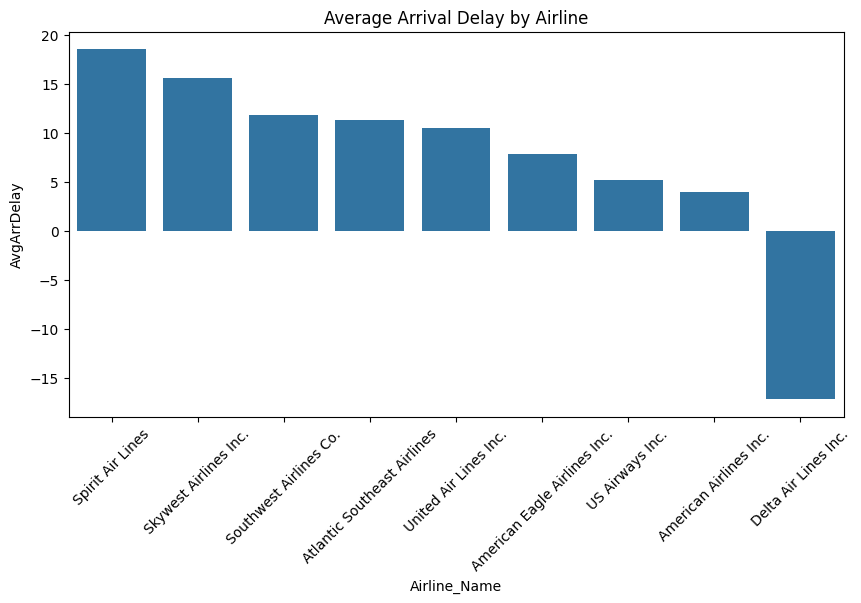

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=airline_delay.sort_values('AvgArrDelay', ascending=False),
    x='Airline_Name',
    y='AvgArrDelay'
)
plt.xticks(rotation=45)
plt.title('Average Arrival Delay by Airline')
plt.show()


##  <font color = 'blue'><b> 7) **Data Mining – Phân cụm hãng bay theo độ trễ (KMeans Clustering)** </b></font><br>

###  <font color = 'purple'><b> a) **Lựa chọn đặc trưng cho bài toán phân cụm** </b></font><br>  
- Ba đặc trưng được lựa chọn để phân cụm bao gồm:  
  - AvgArrDelay: Độ trễ đến trung bình  
  - AvgDepDelay: Độ trễ khởi hành trung bình  
  - DelayRate: Tỷ lệ chuyến bay bị trễ  
&rarr; Các đặc trưng này phản ánh toàn diện hiệu suất vận hành của hãng bay, từ thời điểm khởi hành đến thời điểm hạ cánh.  

###  <font color = 'purple'><b> b) **Chuẩn hóa dữ liệu (Data Scaling)** </b></font><br>  
- Do các đặc trưng có đơn vị và phạm vi giá trị khác nhau (phút và tỷ lệ), dữ liệu cần được chuẩn hóa trước khi áp dụng thuật toán KMeans.
- StandardScaler chuẩn hóa dữ liệu về phân phối có trung bình bằng 0 và độ lệch chuẩn bằng 1  
- Việc chuẩn hóa giúp đảm bảo rằng:  
  - Không có đặc trưng nào chi phối kết quả phân cụm  
  - Thuật toán KMeans hoạt động ổn định và chính xác hơn
###  <font color = 'purple'><b> c) **Áp dụng thuật toán KMeans Clustering** </b></font><br>  
- Thuật toán KMeans được sử dụng để phân cụm các hãng bay dựa trên các đặc trưng đã chuẩn hóa.
  - Số cụm (k = 3) được lựa chọn nhằm: Phân loại các hãng bay thành ba nhóm chính: trễ thấp, trễ trung bình và trễ cao  
  - random_state = 42 giúp đảm bảo kết quả có thể tái lập khi chạy lại mô hình  
- Kết quả phân cụm được lưu vào cột mới Cluster, đại diện cho nhóm mà mỗi hãng bay thuộc về.  
- Sau khi áp dụng KMeans, mỗi hãng bay được gán vào một trong ba cụm có đặc điểm khác nhau:  
  - Cluster 0: Hãng bay có độ trễ thấp, hiệu suất đúng giờ cao
  - Cluster 1: Hãng bay có độ trễ ở mức trung bình
  - Cluster 2: Hãng bay có độ trễ cao, cần cải thiện hiệu quả vận hành  
&rarr; Việc phân cụm giúp chuyển từ phân tích mô tả sang phân tích khám phá, hỗ trợ nhận diện các nhóm hãng bay có hành vi tương đồng về độ trễ.
###  <font color = 'purple'><b> d) **Lý do chọn thuật toán KMean** </b></font><br>  
- Dữ liệu có sẵn không có sẵn nhãn để đánh giá hãng bay nào là tốt hay xấu theo độ trễ vì thế nó thuộc nhóm bài toán học không giám sát.
- Số lượng bản ghi không bị quá lớn, được tổng hợp với đặc trưng là dạng số liên tục (độ trễ trung bình và tỷ lệ trễ).  
- Thuật toán đơn giản, dẽ cài đặt vói các cụm có thể dễ dàng diễn giải thành: nhóm hãng bay có độ trễ thấp, có độ trễ trung bình và có độ trễ cao.  
- Hiệu quả tính toán cao do: thời gian huấn luyện dữ liệu khá là nhanh và khả năng mở rộng tốt khi số lượng dữ liệu tăng.
- Phù hợp với mục tiêu của bài toán là đánh giá hiệu suất của các hãng bay và hỗ trợ đề xuất giải pháp cải thiện độ trễ.  

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['AvgArrDelay', 'AvgDepDelay', 'DelayRate']

X = airline_delay[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
airline_delay['Cluster'] = kmeans.fit_predict(X_scaled)

airline_delay

,Airline_Name,AvgArrDelay,AvgDepDelay,DelayRate,TotalFlights,Cluster
0,American Airlines Inc.,3.924740,10.600658,0.196004,51953,2
1,American Eagle Airlines Inc.,7.775483,14.166592,0.229457,2227,2
2,Atlantic Southeast Airlines,11.293299,12.302116,0.243730,5104,2
3,Delta Air Lines Inc.,-17.176471,2.058824,0.000000,17,0
4,Skywest Airlines Inc.,15.579422,16.903015,0.297793,3217,1
5,Southwest Airlines Co.,11.790373,14.802795,0.307453,1288,1
6,Spirit Air Lines,18.523265,18.555102,0.343061,4900,1
7,US Airways Inc.,5.153726,7.376039,0.189892,14682,2
8,United Air Lines Inc.,10.427228,19.225008,0.243174,18826,1


##  <font color = 'blue'><b> 8) **Phân tích đặc trưng trung bình của từng cụm (Cluster Interpretation)** </b></font><br>
- Sau khi áp dụng thuật toán KMeans, dữ liệu các hãng bay đã được gán vào các cụm khác nhau. Để hiểu rõ đặc điểm của từng cụm, nhóm tiến hành tính giá trị trung bình của các đặc trưng chính theo từng cụm bằng đoạn mã:
- Trong đó:  
  - groupby('Cluster') dùng để nhóm các hãng bay theo cụm được KMeans gán.  
  - [features] bao gồm các đặc trưng phân tích: độ trễ đến trung bình, độ trễ  khởi hành trung bình và tỷ lệ chuyến bay bị trễ.  
  - mean() tính giá trị trung bình của từng đặc trưng trong mỗi cụm.  
- Kết quả thu được giúp mô tả đặc điểm điển hình của từng cụm hãng bay, qua đó hỗ trợ việc diễn giải ý nghĩa của các cluster như: nhóm hãng bay có độ trễ thấp, độ trễ trung bình và độ trễ cao.  


In [ ]:
airline_delay.groupby('Cluster')[features].mean()


,AvgArrDelay,AvgDepDelay,DelayRate
Cluster,,,
0,-17.176471,2.058824,0.000000
1,14.080072,17.371480,0.297870
2,7.036812,11.111351,0.214771


##  <font color = 'blue'><b> 8) **Phân tích đặc trưng trung bình của từng cụm (Cluster Interpretation)** </b></font><br>
Sau khi thực hiện phân cụm bằng thuật toán KMeans, nhóm tiến hành trực quan hóa kết quả để quan sát sự phân bố và mức độ tách biệt giữa các cụm hãng bay. Đoạn mã sau được sử dụng để vẽ biểu đồ phân tán (scatter plot):  
- Biểu đồ phân tán cho phép quan sát trực quan kết quả phân cụm:  
  - Các điểm dữ liệu đại diện cho từng hãng bay  
  - Các màu sắc khác nhau biểu thị các cụm khác nhau do KMeans tạo ra  
  - Có thể dễ dàng nhận thấy sự khác biệt giữa các nhóm hãng bay về mức độ trễ và tỷ lệ trễ  
- Thông qua biểu đồ này, nhóm có thể:  
  - Đánh giá mức độ tách biệt giữa các cụm
  - Nhận diện các hãng bay có hiệu suất đúng giờ tốt (độ trễ thấp, tỷ lệ trễ thấp)
  - Xác định các hãng bay có vấn đề nghiêm trọng về độ trễ


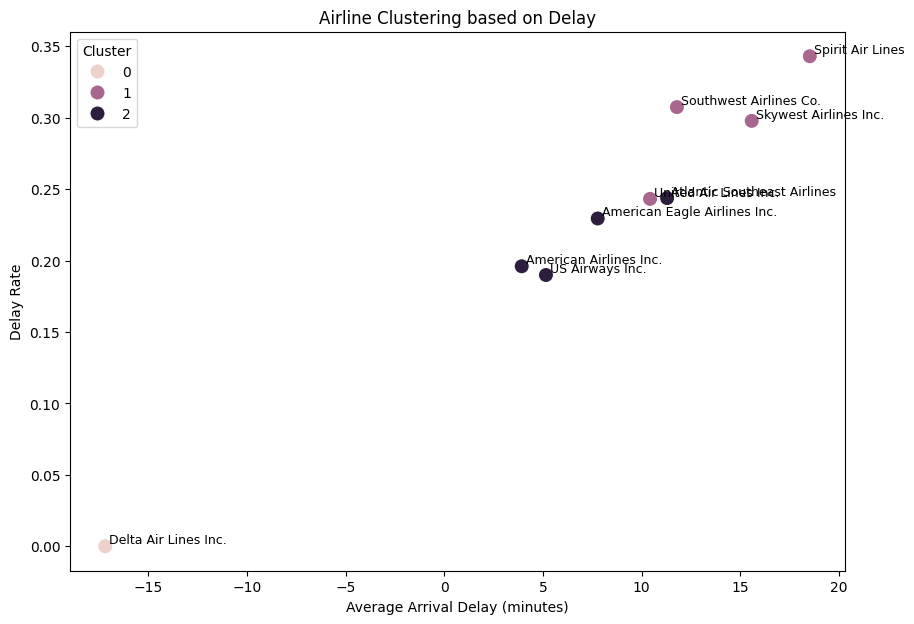

In [40]:
plt.figure(figsize=(10,7))

ax = sns.scatterplot(
    data=airline_delay,
    x='AvgArrDelay',
    y='DelayRate',
    hue='Cluster',
    s=120
)

for _, row in airline_delay.iterrows():
    ax.text(
        row['AvgArrDelay'] + 0.2,
        row['DelayRate'] + 0.002,
        row['Airline_Name'],
        fontsize=9
    )

plt.title('Airline Clustering based on Delay')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Delay Rate')
plt.legend(title='Cluster')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

##  <font color = 'blue'><b> 10) **Data Mining – Dự đoán chuyến bay bị trễ bằng Random Forest** </b></font><br>
- Bên cạnh việc phân cụm các hãng bay theo độ trễ, đồ án tiếp tục áp dụng mô hình học có giám sát nhằm dự đoán khả năng một chuyến bay có bị trễ hay không. Mô hình Random Forest Classifier được sử dụng cho bài toán phân loại nhị phân này.
a. Lựa chọn đặc trưng và mục tiêu
- Trong đó:  
  - Dep_Delay: độ trễ khởi hành, phản ánh trực tiếp khả năng chuyến bay bị trễ  
  - Distance: khoảng cách bay, ảnh hưởng đến thời gian vận hành  
  - Taxi_Out: thời gian lăn bánh trước khi cất cánh, phản ánh tình trạng tắc nghẽn tại sân bay  
- Biến mục tiêu:
  - Is_Delayed: nhãn nhị phân (1: chuyến bay bị trễ, 0: không trễ)

b. Chia dữ liệu huấn luyện và kiểm tra
- Dữ liệu sẽ được chi thành 80% cho tập huấn luyện và 20% cho tập kiểm tra
c. Huấn luyện mô hình Random Forest
- Mô hình Random Forest được huấn luyện trên tập dữ liệu huấn luyện. Thuật toán xây dựng nhiều cây quyết định khác nhau và tổng hợp kết quả để đưa ra dự đoán cuối cùng, giúp tăng độ chính xác và giảm hiện tượng overfitting.
d. Dự đoán và đánh giá mô hình.
- Hàm classification_report cung cấp các chỉ số đánh giá quan trọng:  
  - Precision: tỷ lệ dự đoán đúng trong các chuyến bay được dự đoán là trễ
  - Recall: khả năng phát hiện đúng các chuyến bay thực sự bị trễ
  - F1-score: trung bình điều hòa giữa Precision và Recall
  - Accuracy: độ chính xác tổng thể của mô hình
- Các chỉ số này cho phép đánh giá toàn diện hiệu quả dự đoán của mô hình Random Forest trong bài toán dự đoán chuyến bay bị trễ.  

e. Lý do chọn thuật toán này.  
Trong bài toán dự đoán chuyến bay có bị trễ hay không, nhóm lựa chọn mô hình **Random Forest Classifier** dựa trên các lý do sau:
- Đây là bài toán **phân loại nhị phân** (bị trễ / không bị trễ), phù hợp với Random Forest.
- Random Forest có khả năng xử lý tốt dữ liệu thực tế có nhiễu và mối quan hệ phi tuyến giữa các biến như độ trễ khởi hành, khoảng cách bay và thời gian taxi.
- Mô hình kết hợp nhiều cây quyết định giúp giảm hiện tượng overfitting so với các mô hình đơn lẻ.
- Random Forest không yêu cầu giả định phân phối dữ liệu và hoạt động tốt ngay cả khi các biến đầu vào không tuyến tính.
- Mô hình cho kết quả ổn định, dễ triển khai và được sử dụng phổ biến trong các bài toán dự đoán trong lĩnh vực vận tải và hàng không.  

f. Giải thích các chỉ số trong mô hình
- Precision (Độ chính xác dự đoán): cho biết trong số các chuyến bay được mô hình **dự đoán là bị trễ**, có bao nhiêu chuyến bay thực sự bị trễ.
- Precision lớp **1 (bị trễ)** = 0.87  
→ Khi mô hình dự đoán một chuyến bay bị trễ, có **87% khả năng dự đoán là đúng**.

- Recall (Khả năng phát hiện chuyến bay trễ): cho biết trong số các chuyến bay **thực sự bị trễ**, mô hình phát hiện đúng được bao nhiêu chuyến.  
- Recall lớp **1 (bị trễ)** = 0.77  
→ Mô hình phát hiện đúng **77% các chuyến bay bị trễ**, vẫn còn một số chuyến bay trễ chưa được phát hiện.  

- F1-score: là trung bình điều hòa giữa Precision và Recall, phản ánh hiệu quả tổng thể của mô hình đối với từng lớp.  
- F1-score lớp **1 (bị trễ)** = 0.82   
→ Mô hình đạt hiệu quả khá tốt trong việc cân bằng giữa độ chính xác và khả năng phát hiện chuyến bay trễ.

- Accuracy (Độ chính xác tổng thể): Chỉ số này cho thấy mô hình có hiệu suất tổng thể cao, tuy nhiên cần kết hợp với Precision và Recall để đánh giá chính xác hơn do dữ liệu có sự mất cân bằng giữa số chuyến bay trễ và không trễ  
- Accuracy = **0.93**  
→ Mô hình dự đoán đúng **93% tổng số chuyến bay** trong tập kiểm tra.



In [ ]:
features = ['Dep_Delay', 'Distance', 'Taxi_Out']
X = delay_df[features]
y = delay_df['Is_Delayed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.97      0.95     16038
           1       0.87      0.77      0.82      4405

    accuracy                           0.93     20443
   macro avg       0.90      0.87      0.88     20443
weighted avg       0.92      0.93      0.92     20443



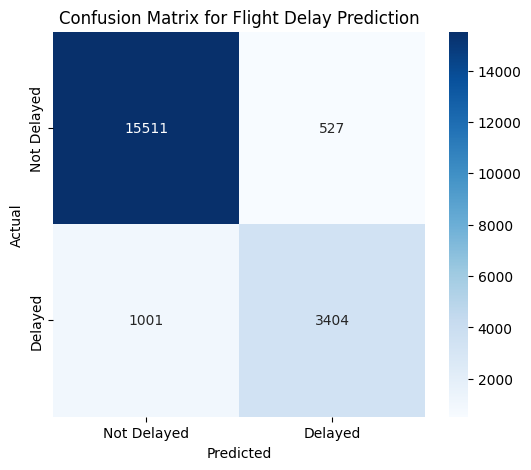

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Delayed', 'Delayed'],
    yticklabels=['Not Delayed', 'Delayed']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Flight Delay Prediction')
plt.show()


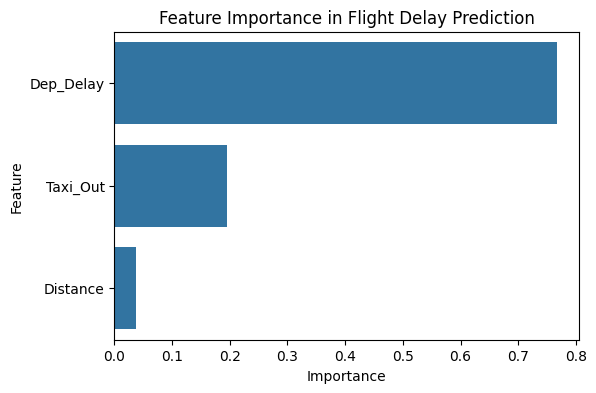

In [42]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Flight Delay Prediction')
plt.show()


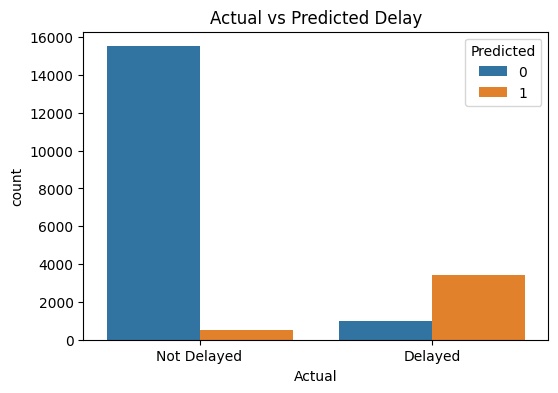

In [43]:
result_df = X_test.copy()
result_df['Actual'] = y_test.values
result_df['Predicted'] = y_pred

plt.figure(figsize=(6,4))
sns.countplot(
    x='Actual',
    hue='Predicted',
    data=result_df
)

plt.xticks([0,1], ['Not Delayed', 'Delayed'])
plt.title('Actual vs Predicted Delay')
plt.show()


- Confusion Matrix: thể hiện số lượng chuyến bay được mô hình dự đoán đúng và sai giữa hai lớp bị trễ và không bị trễ, giúp đánh giá trực quan hiệu quả dự đoán của mô hình.
- Feature Importance: cho biết mức độ ảnh hưởng của từng biến đầu vào đến kết quả dự đoán, qua đó xác định các yếu tố quan trọng nhất gây ra độ trễ chuyến bay.
- Actual vs Predicted Distribution: Biểu đồ phân phối so sánh giữa nhãn thực tế và nhãn dự đoán, giúp quan sát khả năng dự đoán đúng và sai của mô hình đối với từng nhóm chuyến bay.